# Оценка на задаче удержания

В этом ноутбуке оценивается прикладная полезность последовательностных эмбеддингов в задаче предсказания удержания пользователей. Основной вопрос этапа: добавляют ли `GRU` и `LSTM` полезную информацию поверх простых пользовательских признаков и что сильнее влияет на downstream-качество — длина раннего префикса или выбор рекуррентной архитектуры.


## План
1. Загрузить подготовленные последовательности, split и обученные рекуррентные модели.
2. Построить корректные prefix-based метки для `retention_7d` и `retention_14d` без утечки по времени.
3. Провести абляцию по длине наблюдаемого префикса `50/100/150` для `GRU`.
4. Зафиксировать рабочий префикс `PREFIX_LEN=150` и на нём сравнить `Baseline`, `GRU`, `LSTM`, `Baseline + GRU`, `Baseline + LSTM`.
5. Свести результаты в общую таблицу и показать, что даёт увеличение префикса и что даёт замена `GRU` на `LSTM`.


In [1]:
from collections import Counter
from pathlib import Path
import json
import re
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import polars as pl
import torch
from sklearn.metrics import average_precision_score, roc_auc_score, roc_curve
from xgboost import XGBClassifier

from src.data import load_prepared_sequences
from src.models import GRUEncoder, LSTMEncoder
from src.splits import apply_user_split, load_user_split
from src.train import choose_device, seed_everything

plt.style.use('seaborn-v0_8-whitegrid')
pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(20)

polars.config.Config

In [2]:
DATA_DIR = PROJECT_ROOT / 'artifacts' / 'data'
RNN_DIR = PROJECT_ROOT / 'artifacts' / 'rnn'
DOWNSTREAM_DIR = PROJECT_ROOT / 'artifacts' / 'downstream'
DOWNSTREAM_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
PREFIX_LENGTHS = [50, 100, 150]
BEST_PREFIX_LEN = 150
TOP_K_EVENTS = 10
HORIZONS = {'retention_7d': 7, 'retention_14d': 14}
SECONDS_IN_DAY = 86400

print(f'DATA_DIR={DATA_DIR}')
print(f'RNN_DIR={RNN_DIR}')
print(f'DOWNSTREAM_DIR={DOWNSTREAM_DIR}')
print(
    f'SEED={SEED}, PREFIX_LENGTHS={PREFIX_LENGTHS}, BEST_PREFIX_LEN={BEST_PREFIX_LEN}, '
    f'TOP_K_EVENTS={TOP_K_EVENTS}, HORIZONS={HORIZONS}'
)

DATA_DIR=/Users/fedornikonov/hse_recsys_rnn/artifacts/data
RNN_DIR=/Users/fedornikonov/hse_recsys_rnn/artifacts/rnn
DOWNSTREAM_DIR=/Users/fedornikonov/hse_recsys_rnn/artifacts/downstream
SEED=42, PREFIX_LENGTHS=[50, 100, 150], BEST_PREFIX_LEN=150, TOP_K_EVENTS=10, HORIZONS={'retention_7d': 7, 'retention_14d': 14}


## 1. Загрузка артефактов и фиксированного split

Downstream-оценка строится поверх тех же пользователей и тех же последовательностей, которые использовались на предыдущих этапах. Это обеспечивает сопоставимость результатов между sequence-постановкой и прикладной задачей.


In [3]:
prepared = load_prepared_sequences(DATA_DIR)
split = load_user_split(DATA_DIR / 'split.json')
split_prepared = apply_user_split(prepared, split)

train_prepared = split_prepared['train']
val_prepared = split_prepared['val']
test_prepared = split_prepared['test']

split_users_df = pl.read_parquet(DATA_DIR / 'split_users.parquet')

print(f'total_users={len(prepared.user_ids)}')
print(f'train_users={len(train_prepared.user_ids)}')
print(f'val_users={len(val_prepared.user_ids)}')
print(f'test_users={len(test_prepared.user_ids)}')

total_users=52495
train_users=36760
val_users=7896
test_users=7839


Вывод.

Downstream-оценка строится на том же наборе из **52,495** пользователей, что и предыдущие этапы, а split по пользователям остаётся фиксированным. Это позволяет интерпретировать различия в метриках как эффект набора признаков, а не как следствие другого разбиения данных.


## 2. Prefix-based metadata и retention labels
Сначала строится единая пользовательская мета-таблица с полными временными рядами событий и сессий. Для downstream-оценки используются только пользователи, у которых реально есть полный префикс нужной длины; короткие истории исключаются из оценки, если для них нельзя корректно посчитать label, чтобы не превращать задачу в тривиальное определение churn по факту конца истории. Затем для каждого значения `PREFIX_LEN` из списка `50/100/150` из неё извлекаются prefix-based признаки и labels. Это позволяет сравнивать длины префикса в одной и той же постановке без дублирования кода.


In [4]:
clean_glob = str(DATA_DIR / 'clean_events' / '*.parquet')

base_meta_df = (
    pl.scan_parquet(clean_glob)
    .select([
        pl.col('appmetrica_device_id').cast(pl.String),
        pl.col('event_timestamp').cast(pl.Int64),
        pl.col('session_id').cast(pl.Int64, strict=False),
        pl.col('row_id').cast(pl.Int64),
    ])
    .sort(['appmetrica_device_id', 'event_timestamp', 'row_id'])
    .group_by('appmetrica_device_id', maintain_order=True)
    .agg([
        pl.col('event_timestamp').alias('all_timestamps'),
        pl.col('session_id').alias('all_sessions'),
        pl.col('event_timestamp').last().alias('last_event_ts'),
    ])
    .collect()
    .filter(pl.col('appmetrica_device_id').is_in(prepared.user_ids))
)

data_end_ts = int(base_meta_df['last_event_ts'].max())


def build_meta_for_prefix(prefix_len: int) -> tuple[pl.DataFrame, pl.DataFrame]:
    meta_df = base_meta_df.with_columns([
        pl.col('all_timestamps').list.slice(0, prefix_len).alias('prefix_timestamps'),
        pl.col('all_sessions').list.slice(0, prefix_len).alias('prefix_sessions'),
    ]).with_columns([
        pl.col('prefix_timestamps').list.len().alias('prefix_len_time'),
        pl.col('prefix_timestamps').list.last().alias('prefix_end_ts'),
        pl.col('prefix_sessions').list.n_unique().alias('prefix_session_count'),
        pl.col('prefix_timestamps').list.eval(pl.element() // SECONDS_IN_DAY).list.n_unique().alias('prefix_active_days'),
    ])

    for label_name, horizon_days in HORIZONS.items():
        horizon_seconds = horizon_days * SECONDS_IN_DAY
        meta_df = meta_df.with_columns(
            pl.when((pl.col('prefix_len_time') == prefix_len) & (pl.col('prefix_end_ts') + horizon_seconds <= data_end_ts))
            .then((pl.col('last_event_ts') >= pl.col('prefix_end_ts') + horizon_seconds).cast(pl.Int8))
            .otherwise(None)
            .alias(label_name)
        )

    label_summary_rows = []
    for label_name in HORIZONS:
        valid = meta_df.filter(pl.col(label_name).is_not_null())
        label_summary_rows.append(
            {
                'prefix_len': prefix_len,
                'label': label_name,
                'valid_users': valid.height,
                'positive_rate': float(valid[label_name].mean()) if valid.height > 0 else None,
            }
        )

    return meta_df, pl.DataFrame(label_summary_rows)


meta_by_prefix = {}
label_summary_dfs = []
for prefix_len in PREFIX_LENGTHS:
    meta_df, label_summary_df = build_meta_for_prefix(prefix_len)
    meta_by_prefix[prefix_len] = meta_df
    label_summary_dfs.append(label_summary_df)

label_summary_df = pl.concat(label_summary_dfs).sort(['label', 'prefix_len'])
label_summary_df

prefix_len,label,valid_users,positive_rate
i64,str,i64,f64
50,"""retention_14d""",21685,0.1454
100,"""retention_14d""",17369,0.168288
150,"""retention_14d""",15207,0.181758
50,"""retention_7d""",26597,0.223785
100,"""retention_7d""",21218,0.259685
150,"""retention_7d""",18547,0.281124


Вывод.

В финальном downstream-протоколе короткие истории не получают автоматический negative label. Для каждого `PREFIX_LEN` в оценке остаются только пользователи, у которых реально есть полный наблюдаемый префикс нужной длины и достаточный будущий горизонт для проверки удержания.

Из-за этого при росте `PREFIX_LEN` размер тестовой выборки заметно уменьшается. Для `retention_7d` на `test` остаётся `4025` пользователей при `PREFIX_LEN=50`, `3195` при `100` и `2805` при `150`. Для `retention_14d` — `3274`, `2617` и `2303` соответственно. Это делает задачу честнее: модель больше не может получать высокое качество за счёт простого отделения коротких завершённых историй.


## 3. Baseline и prefix-based эмбеддинги
Сначала проводится ablation по длине префикса для `GRU`. После этого на заранее выбранном рабочем префиксе `PREFIX_LEN=150` добавляется `LSTM` как модельная проверка: можно ли улучшить downstream-качество не за счёт большего окна наблюдения, а за счёт другой рекуррентной архитектуры.


In [5]:
id2event = {idx: event for event, idx in prepared.event2idx.items()}


def slugify(name: str) -> str:
    name = name.lower()
    name = re.sub(r'[^a-z0-9]+', '_', name)
    return name.strip('_')


def build_baseline_features(prefix_len: int, meta_df: pl.DataFrame):
    train_prefix_counter = Counter()
    for seq in train_prepared.user_sequences:
        train_prefix_counter.update(seq[:prefix_len])

    top_event_ids = [event_id for event_id, _ in train_prefix_counter.most_common(TOP_K_EVENTS)]
    top_event_names = [id2event[event_id] for event_id in top_event_ids]
    top_event_feature_names = [f"share_{slugify(name)}" for name in top_event_names]

    rows = []
    for user_id, seq in zip(prepared.user_ids, prepared.user_sequences, strict=True):
        prefix_seq = seq[:prefix_len]
        prefix_len_actual = len(prefix_seq)
        prefix_counter = Counter(prefix_seq)
        unique_event_count = len(prefix_counter)
        repeat_ratio = 1.0 - (unique_event_count / prefix_len_actual) if prefix_len_actual else 0.0

        row = {
            'appmetrica_device_id': user_id,
            'prefix_len_feature': prefix_len_actual,
            'unique_event_count': unique_event_count,
            'repeat_ratio': repeat_ratio,
        }
        for feature_name, event_id in zip(top_event_feature_names, top_event_ids, strict=True):
            row[feature_name] = prefix_counter.get(event_id, 0) / max(prefix_len_actual, 1)
        rows.append(row)

    baseline_features_df = pl.DataFrame(rows).join(
        meta_df.select([
            'appmetrica_device_id',
            'prefix_session_count',
            'prefix_active_days',
            *HORIZONS.keys(),
        ]),
        on='appmetrica_device_id',
        how='inner',
    ).join(split_users_df, on='appmetrica_device_id', how='inner')

    baseline_feature_cols = [
        'prefix_len_feature',
        'unique_event_count',
        'repeat_ratio',
        'prefix_session_count',
        'prefix_active_days',
        *top_event_feature_names,
    ]
    feature_summary_df = pl.DataFrame(
        {
            'prefix_len': [prefix_len],
            'feature_group': ['baseline'],
            'num_features': [len(baseline_feature_cols)],
            'top_events_used': [', '.join(top_event_names)],
        }
    )
    return baseline_features_df, baseline_feature_cols, feature_summary_df

In [6]:
seed_everything(SEED)
device = choose_device()

def load_recurrent_model(model_path: Path, config_path: Path):
    checkpoint = torch.load(model_path, map_location='cpu')
    config = json.loads(config_path.read_text(encoding='utf-8'))
    model_type = config.get('model_type', 'gru').lower()
    model_cls = GRUEncoder if model_type == 'gru' else LSTMEncoder
    model = model_cls(
        vocab_size=len(prepared.event2idx),
        event_dim=config['event_dim'],
        hidden_dim=config['hidden_dim'],
        num_layers=config['num_layers'],
        dropout=config['dropout'],
    ).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    return model, model_type.upper()


def build_prefix_embeddings(model, prefix_len: int) -> pl.DataFrame:
    embedding_rows = []
    user_ids = prepared.user_ids
    sequences = prepared.user_sequences

    with torch.no_grad():
        for offset in range(0, len(user_ids), 256):
            batch_user_ids = user_ids[offset: offset + 256]
            batch_sequences = [seq[:prefix_len] for seq in sequences[offset: offset + 256]]
            lengths = torch.tensor([len(seq) for seq in batch_sequences], dtype=torch.long)
            padded = [seq + [0] * (prefix_len - len(seq)) for seq in batch_sequences]
            batch_x = torch.tensor(padded, dtype=torch.long, device=device)
            batch_embeddings = model.encode(batch_x, lengths.to(device)).cpu().numpy()
            for user_id, emb in zip(batch_user_ids, batch_embeddings, strict=True):
                row = {'appmetrica_device_id': user_id}
                for idx, value in enumerate(emb.tolist()):
                    row[f'emb_{idx:03d}'] = float(value)
                embedding_rows.append(row)

    return pl.DataFrame(embedding_rows).join(split_users_df, on='appmetrica_device_id', how='inner')


gru_model, _ = load_recurrent_model(RNN_DIR / 'rnn_encoder.pt', RNN_DIR / 'rnn_config.json')
lstm_model, _ = load_recurrent_model(RNN_DIR / 'lstm_encoder.pt', RNN_DIR / 'lstm_config.json')

baseline_feature_sets = {}
gru_embedding_sets = {}
feature_summary_dfs = []

for prefix_len in PREFIX_LENGTHS:
    baseline_features_df, baseline_feature_cols, feature_summary_df = build_baseline_features(prefix_len, meta_by_prefix[prefix_len])
    gru_embeddings_df = build_prefix_embeddings(gru_model, prefix_len)

    baseline_feature_sets[prefix_len] = {
        'df': baseline_features_df,
        'feature_cols': baseline_feature_cols,
    }
    gru_embedding_sets[prefix_len] = gru_embeddings_df
    feature_summary_dfs.append(feature_summary_df)

lstm_best_embeddings_df = build_prefix_embeddings(lstm_model, BEST_PREFIX_LEN)

feature_summary_df = pl.concat(feature_summary_dfs).sort('prefix_len')
feature_summary_df

prefix_len,feature_group,num_features,top_events_used
i64,str,i64,str
50,"""baseline""",15,"""REWARD, machine_learning, Trai…"
100,"""baseline""",15,"""REWARD, machine_learning, Trai…"
150,"""baseline""",15,"""REWARD, machine_learning, Trai…"


Вывод.

После построения признаков есть две группы экспериментов. Первая — ablation `GRU` по длине полного префикса `50/100/150`, где число пользователей меняется вместе с требованием к длине истории. Вторая — сравнение `GRU` и `LSTM` при фиксированном `PREFIX_LEN=150` на одной и той же выборке.

Downstream-оценка-таблицы не содержат пользователей с неполным префиксом. Поэтому метрики отражают более строгую постановку: признаки строятся только по наблюдаемому префиксу, а метка считается только при наличии полного будущего горизонта.


## 4. Объединение признаков и подготовка downstream-таблиц
Для `GRU` сохраняется полная сетка по трём длинам префикса. Для `LSTM` отдельно собирается downstream-таблица только на рабочем значении `PREFIX_LEN=150`, чтобы модельная ablation не смешивалась с абляцией по длине истории.


In [7]:
downstream_by_prefix = {}
split_label_rows = []

for prefix_len in PREFIX_LENGTHS:
    baseline_features_df = baseline_feature_sets[prefix_len]['df']
    baseline_feature_cols = baseline_feature_sets[prefix_len]['feature_cols']
    gru_embeddings_df = gru_embedding_sets[prefix_len]

    downstream_df = baseline_features_df.join(
        gru_embeddings_df.drop('split'),
        on='appmetrica_device_id',
        how='inner',
    )

    embedding_feature_cols = [column for column in downstream_df.columns if column.startswith('emb_')]
    combined_feature_cols = baseline_feature_cols + embedding_feature_cols

    downstream_by_prefix[prefix_len] = {
        'df': downstream_df,
        'baseline_feature_cols': baseline_feature_cols,
        'embedding_feature_cols': embedding_feature_cols,
        'combined_feature_cols': combined_feature_cols,
    }

    for split_name in ['train', 'val', 'test']:
        for label_name in HORIZONS:
            valid = downstream_df.filter((pl.col('split') == split_name) & pl.col(label_name).is_not_null())
            split_label_rows.append(
                {
                    'prefix_len': prefix_len,
                    'split': split_name,
                    'label': label_name,
                    'valid_users': valid.height,
                    'positive_rate': float(valid[label_name].mean()) if valid.height > 0 else None,
                }
            )

best_baseline_df = baseline_feature_sets[BEST_PREFIX_LEN]['df']
best_baseline_feature_cols = baseline_feature_sets[BEST_PREFIX_LEN]['feature_cols']
best_gru_df = downstream_by_prefix[BEST_PREFIX_LEN]['df']
best_gru_embedding_cols = downstream_by_prefix[BEST_PREFIX_LEN]['embedding_feature_cols']

best_lstm_df = best_baseline_df.join(
    lstm_best_embeddings_df.drop('split'),
    on='appmetrica_device_id',
    how='inner',
)
best_lstm_embedding_cols = [column for column in best_lstm_df.columns if column.startswith('emb_')]
best_lstm_combined_cols = best_baseline_feature_cols + best_lstm_embedding_cols

split_label_summary_df = pl.DataFrame(split_label_rows).sort(['prefix_len', 'split', 'label'])
split_label_summary_df

prefix_len,split,label,valid_users,positive_rate
i64,str,str,i64,f64
50,"""test""","""retention_14d""",3274,0.152718
50,"""test""","""retention_7d""",4025,0.224099
50,"""train""","""retention_14d""",15135,0.143244
50,"""train""","""retention_7d""",18621,0.220128
50,"""val""","""retention_14d""",3276,0.148046
50,"""val""","""retention_7d""",3951,0.240699
100,"""test""","""retention_14d""",2617,0.173863
100,"""test""","""retention_7d""",3195,0.261346
100,"""train""","""retention_14d""",12106,0.166364


Вывод.

Для `GRU` готова сетка по трём длинам полного префикса. Для `PREFIX_LEN=150` дополнительно готова таблица с `LSTM`-эмбеддингами, что позволяет сравнивать архитектуры на одинаковой downstream-выборке: `2805` test-пользователей для `retention_7d` и `2303` для `retention_14d`.


## 5. Оценка `XGBoost`: ablation prefix-based и сравнение архитектур
Этот шаг делится на две части:
- сначала повторяется ablation `GRU` по `50/100/150`;
- затем на рабочем `PREFIX_LEN=150` проводится отдельное сравнение `Baseline`, `GRU`, `LSTM`, `Baseline + GRU`, `Baseline + LSTM`.


In [8]:
def evaluate_feature_set(df: pl.DataFrame, feature_cols: list[str], label_col: str, feature_set_name: str):
    train_df = df.filter((pl.col('split') == 'train') & pl.col(label_col).is_not_null())
    val_df = df.filter((pl.col('split') == 'val') & pl.col(label_col).is_not_null())
    test_df = df.filter((pl.col('split') == 'test') & pl.col(label_col).is_not_null())

    X_train = train_df.select(feature_cols).to_numpy()
    y_train = train_df[label_col].to_numpy().astype(int)

    model = XGBClassifier(
        n_estimators=250,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective='binary:logistic',
        eval_metric='logloss',
        tree_method='hist',
        random_state=SEED,
        verbosity=0,
    )
    model.fit(X_train, y_train)

    rows = []
    roc_payload = {}
    for split_name, split_df in [('val', val_df), ('test', test_df)]:
        X_split = split_df.select(feature_cols).to_numpy()
        y_split = split_df[label_col].to_numpy().astype(int)
        y_prob = model.predict_proba(X_split)[:, 1]

        rows.append(
            {
                'feature_set': feature_set_name,
                'label': label_col,
                'split': split_name,
                'roc_auc': float(roc_auc_score(y_split, y_prob)),
                'pr_auc': float(average_precision_score(y_split, y_prob)),
                'num_users': int(len(y_split)),
            }
        )
        roc_payload[(feature_set_name, label_col, split_name)] = (y_split, y_prob)

    return rows, roc_payload


all_rows = []
roc_payload = {}
for prefix_len in PREFIX_LENGTHS:
    downstream_bundle = downstream_by_prefix[prefix_len]
    downstream_df = downstream_bundle['df']

    for label_name in HORIZONS:
        for feature_set_name, feature_cols in [
            ('Baseline', downstream_bundle['baseline_feature_cols']),
            ('GRU', downstream_bundle['embedding_feature_cols']),
            ('Baseline + GRU', downstream_bundle['combined_feature_cols']),
        ]:
            rows, roc_info = evaluate_feature_set(downstream_df, feature_cols, label_name, feature_set_name)
            for row in rows:
                row['prefix_len'] = prefix_len
                row['experiment'] = 'gru_prefix_ablation'
            all_rows.extend(rows)
            for key, value in roc_info.items():
                roc_payload[('gru_prefix_ablation', prefix_len, *key)] = value

for label_name in HORIZONS:
    for feature_set_name, df, feature_cols in [
        ('Baseline', best_baseline_df, best_baseline_feature_cols),
        ('GRU', best_gru_df, best_gru_embedding_cols),
        ('LSTM', best_lstm_df, best_lstm_embedding_cols),
        ('Baseline + GRU', best_gru_df, best_baseline_feature_cols + best_gru_embedding_cols),
        ('Baseline + LSTM', best_lstm_df, best_lstm_combined_cols),
    ]:
        rows, roc_info = evaluate_feature_set(df, feature_cols, label_name, feature_set_name)
        for row in rows:
            row['prefix_len'] = BEST_PREFIX_LEN
            row['experiment'] = 'best_prefix_model_comparison'
        all_rows.extend(rows)
        for key, value in roc_info.items():
            roc_payload[('best_prefix_model_comparison', BEST_PREFIX_LEN, *key)] = value

downstream_metrics_df = pl.DataFrame(all_rows).select([
    'experiment', 'prefix_len', 'feature_set', 'label', 'split', 'roc_auc', 'pr_auc', 'num_users'
]).sort(['experiment', 'prefix_len', 'label', 'split', 'feature_set'])
downstream_metrics_df

experiment,prefix_len,feature_set,label,split,roc_auc,pr_auc,num_users
str,i64,str,str,str,f64,f64,i64
"""best_prefix_model_comparison""",150,"""Baseline""","""retention_14d""","""test""",0.683047,0.343962,2303
"""best_prefix_model_comparison""",150,"""Baseline + GRU""","""retention_14d""","""test""",0.685828,0.34043,2303
"""best_prefix_model_comparison""",150,"""Baseline + LSTM""","""retention_14d""","""test""",0.690498,0.347091,2303
"""best_prefix_model_comparison""",150,"""GRU""","""retention_14d""","""test""",0.686477,0.340033,2303
"""best_prefix_model_comparison""",150,"""LSTM""","""retention_14d""","""test""",0.687634,0.35077,2303
"""best_prefix_model_comparison""",150,"""Baseline""","""retention_14d""","""val""",0.697577,0.341101,2318
"""best_prefix_model_comparison""",150,"""Baseline + GRU""","""retention_14d""","""val""",0.70083,0.349629,2318
"""best_prefix_model_comparison""",150,"""Baseline + LSTM""","""retention_14d""","""val""",0.698798,0.33725,2318
"""best_prefix_model_comparison""",150,"""GRU""","""retention_14d""","""val""",0.69825,0.346641,2318


Вывод.

В этом блоке разведены две гипотезы: влияет ли длина полного раннего префикса и даёт ли `LSTM` выигрыш относительно `GRU`. После удаления коротких историй задача стала заметно сложнее: downstream ROC-AUC больше не находится около `0.88`, а лежит примерно в диапазоне `0.65-0.70`. Это ожидаемый результат: прежняя высокая метрика частично объяснялась тривиальным сигналом `sequence_len < prefix_len`.


## 6. Визуализация downstream-результатов
Здесь сравнение сводится в два компактных блока:
- изменение `ROC-AUC` и `PR-AUC` по мере роста `PREFIX_LEN` для `GRU`;
- отдельное сравнение `Baseline`, `GRU`, `LSTM`, `Baseline + GRU`, `Baseline + LSTM` на рабочем префиксе `PREFIX_LEN=150`.



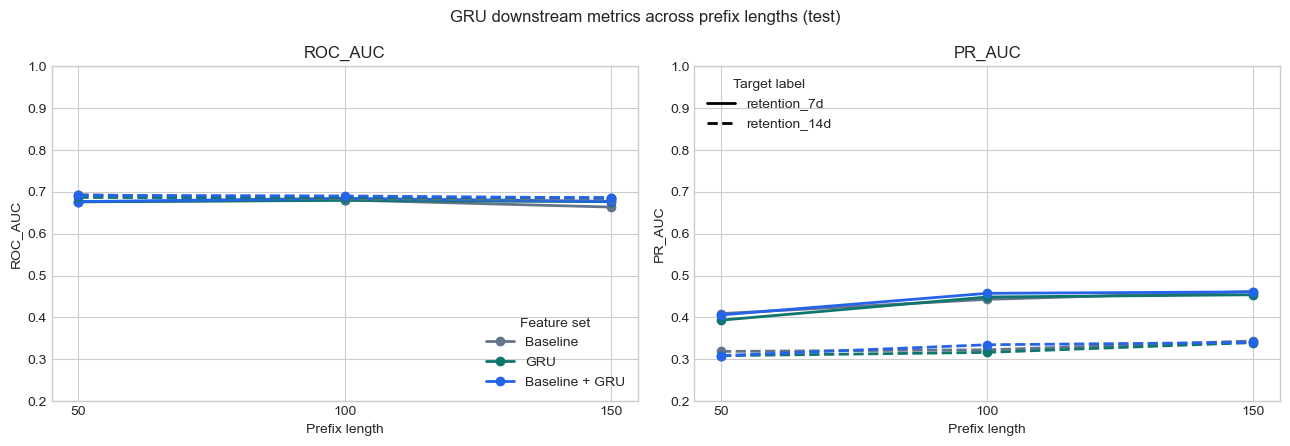

feature_set,label,roc_auc_50,roc_auc_100,roc_auc_150,pr_auc_50,pr_auc_100,pr_auc_150
str,str,f64,f64,f64,f64,f64,f64
"""Baseline""","""retention_14d""",0.69343,0.683322,0.683047,0.318854,0.322835,0.343962
"""Baseline + GRU""","""retention_14d""",0.69204,0.690396,0.685828,0.308941,0.334812,0.34043
"""GRU""","""retention_14d""",0.686841,0.68596,0.686477,0.308703,0.316596,0.340033
"""Baseline""","""retention_7d""",0.676552,0.680851,0.663872,0.409242,0.443319,0.46206
"""Baseline + GRU""","""retention_7d""",0.677004,0.68463,0.677648,0.406125,0.457751,0.461224
"""GRU""","""retention_7d""",0.676295,0.679848,0.676638,0.393542,0.448979,0.454262


In [9]:
from matplotlib.lines import Line2D

gru_test_metrics_df = (
    downstream_metrics_df
    .filter((pl.col('experiment') == 'gru_prefix_ablation') & (pl.col('split') == 'test'))
    .sort(['label', 'feature_set', 'prefix_len'])
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
feature_colors = {'Baseline': '#64748b', 'GRU': '#0f766e', 'Baseline + GRU': '#2563eb'}
label_styles = {'retention_7d': '-', 'retention_14d': '--'}

for ax, metric in zip(axes, ['roc_auc', 'pr_auc']):
    for label_name, linestyle in label_styles.items():
        for feature_set_name, color in feature_colors.items():
            subset = (
                gru_test_metrics_df
                .filter((pl.col('label') == label_name) & (pl.col('feature_set') == feature_set_name))
                .sort('prefix_len')
            )
            ax.plot(
                subset['prefix_len'].to_list(),
                subset[metric].to_list(),
                marker='o',
                linestyle=linestyle,
                color=color,
                linewidth=2,
            )
    ax.set_title(metric.upper())
    ax.set_xlabel('Prefix length')
    ax.set_ylabel(metric.upper())
    ax.set_xticks(PREFIX_LENGTHS)
    ax.set_ylim(0.2, 1.0)

feature_handles = [Line2D([0], [0], color=color, lw=2, marker='o', label=name) for name, color in feature_colors.items()]
label_handles = [Line2D([0], [0], color='black', lw=2, linestyle=style, label=name) for name, style in label_styles.items()]

axes[0].legend(handles=feature_handles, title='Feature set', loc='lower right')
axes[1].legend(handles=label_handles, title='Target label', loc='upper left')
fig.suptitle('GRU downstream metrics across prefix lengths (test)')
plt.tight_layout()
plt.show()

gru_ablation_summary_df = gru_test_metrics_df.pivot(
    on='prefix_len',
    index=['feature_set', 'label'],
    values=['roc_auc', 'pr_auc'],
    aggregate_function='first',
).sort(['label', 'feature_set'])
gru_ablation_summary_df

В финальном протоколе увеличение `PREFIX_LEN` не даёт монотонного роста ROC-AUC. На `test` для `retention_7d` чистый `GRU` имеет ROC-AUC `0.6763 / 0.6798 / 0.6766` для `50 / 100 / 150`, а для `retention_14d` — `0.6868 / 0.6860 / 0.6865`. Tabular baseline также не улучшается монотонно: например, для `retention_7d` ROC-AUC сначала растёт с `0.6766` при `50` до `0.6809` при `100`, но затем снижается до `0.6639` при `150`.

Это означает, что context-length ablation нужно интерпретировать осторожно: при росте `prefix_len` меняется не только количество доступной истории, но и состав пользователей, для которых label остаётся валидным. Для финального сравнения нужен отдельный анализ на общем множестве валидных пользователей.

### Сравнение `GRU` и `LSTM` на рабочем префиксе
Теперь, когда `PREFIX_LEN=150` зафиксирован, можно сравнить две рекуррентные архитектуры напрямую. Здесь уже нет абляции по длине истории: меняется только тип sequence representation и комбинация с табличными baseline-признаками.


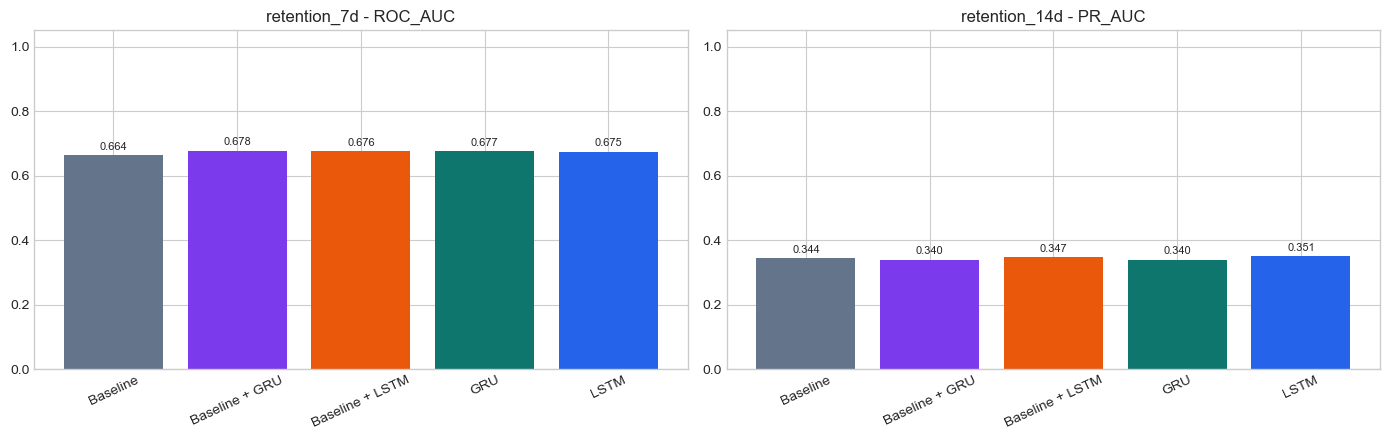

In [10]:
best_prefix_test_df = (
    downstream_metrics_df
    .filter((pl.col('experiment') == 'best_prefix_model_comparison') & (pl.col('split') == 'test'))
    .sort(['label', 'feature_set'])
)

model_comparison_plot_df = best_prefix_test_df.filter(
    pl.col('feature_set').is_in(['Baseline', 'GRU', 'LSTM', 'Baseline + GRU', 'Baseline + LSTM'])
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
model_colors = {
    'Baseline': '#64748b',
    'GRU': '#0f766e',
    'LSTM': '#2563eb',
    'Baseline + GRU': '#7c3aed',
    'Baseline + LSTM': '#ea580c',
}
for ax, metric, label_name in zip(axes, ['roc_auc', 'pr_auc'], ['retention_7d', 'retention_14d']):
    subset = model_comparison_plot_df.filter(pl.col('label') == label_name).sort('feature_set')
    models = subset['feature_set'].to_list()
    values = subset[metric].to_list()
    colors = [model_colors[m] for m in models]
    ax.bar(models, values, color=colors)
    ax.set_title(f'{label_name} - {metric.upper()}')
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=25)
    for idx, value in enumerate(values):
        ax.text(idx, value + 0.01, f'{value:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [11]:
best_prefix_test_df

experiment,prefix_len,feature_set,label,split,roc_auc,pr_auc,num_users
str,i64,str,str,str,f64,f64,i64
"""best_prefix_model_comparison""",150,"""Baseline""","""retention_14d""","""test""",0.683047,0.343962,2303
"""best_prefix_model_comparison""",150,"""Baseline + GRU""","""retention_14d""","""test""",0.685828,0.34043,2303
"""best_prefix_model_comparison""",150,"""Baseline + LSTM""","""retention_14d""","""test""",0.690498,0.347091,2303
"""best_prefix_model_comparison""",150,"""GRU""","""retention_14d""","""test""",0.686477,0.340033,2303
"""best_prefix_model_comparison""",150,"""LSTM""","""retention_14d""","""test""",0.687634,0.35077,2303
"""best_prefix_model_comparison""",150,"""Baseline""","""retention_7d""","""test""",0.663872,0.46206,2805
"""best_prefix_model_comparison""",150,"""Baseline + GRU""","""retention_7d""","""test""",0.677648,0.461224,2805
"""best_prefix_model_comparison""",150,"""Baseline + LSTM""","""retention_7d""","""test""",0.675674,0.468093,2805
"""best_prefix_model_comparison""",150,"""GRU""","""retention_7d""","""test""",0.676638,0.454262,2805


Для `retention_7d` на `test` baseline имеет ROC-AUC `0.6639`, `GRU` — `0.6766`, `LSTM` — `0.6746`. Комбинации дают небольшой прирост: лучший ROC-AUC в этом блоке у `Baseline + GRU` — `0.6776`, а лучший PR-AUC почти совпадает у `LSTM` и `Baseline + LSTM` — около `0.4681`.

Для `retention_14d` baseline имеет ROC-AUC `0.6830`, чистый `GRU` — `0.6865`, а чистый `LSTM` — `0.6876`. Лучший ROC-AUC даёт `Baseline + LSTM` (`0.6905`), при этом лучший PR-AUC у чистого `LSTM` (`0.3508`) против `0.3440` у baseline. Поэтому вывод по архитектурам аккуратный: `LSTM` иногда помогает на фиксированном `prefix_len=150`, но преимущество небольшое и не отменяет дальнейший фокус на более простой `GRU` с лучшими pooling-стратегиями.

## 7. Сохранение downstream-результатов
Сохраняются:
- общая таблица метрик, включающая и абляцию по `GRU`, и сравнение `GRU/LSTM` на рабочем префиксе `PREFIX_LEN=150`;
- downstream-таблица и prefix-эмбеддинги для рабочего `GRU`-варианта при `PREFIX_LEN=150`;
- отдельные `LSTM`-эмбеддинги для `PREFIX_LEN=150`;
- конфиг эксперимента.


In [12]:
best_gru_downstream_df = downstream_by_prefix[BEST_PREFIX_LEN]['df']
best_gru_prefix_embeddings_df = gru_embedding_sets[BEST_PREFIX_LEN]
best_lstm_prefix_embeddings_df = lstm_best_embeddings_df
embedding_feature_cols = downstream_by_prefix[BEST_PREFIX_LEN]['embedding_feature_cols']

prefix_embeddings_path = DOWNSTREAM_DIR / 'prefix_gru_embeddings.parquet'
lstm_prefix_embeddings_path = DOWNSTREAM_DIR / 'prefix_lstm_embeddings.parquet'
downstream_table_path = DOWNSTREAM_DIR / 'downstream_table.parquet'
metrics_path = DOWNSTREAM_DIR / 'downstream_metrics.csv'
config_path = DOWNSTREAM_DIR / 'downstream_config.json'

best_gru_prefix_embeddings_df.write_parquet(prefix_embeddings_path)
best_lstm_prefix_embeddings_df.write_parquet(lstm_prefix_embeddings_path)
best_gru_downstream_df.write_parquet(downstream_table_path)
downstream_metrics_df.write_csv(metrics_path)
config_path.write_text(
    json.dumps(
        {
            'seed': SEED,
            'prefix_lengths': PREFIX_LENGTHS,
            'best_prefix_len': BEST_PREFIX_LEN,
            'top_k_events': TOP_K_EVENTS,
            'horizons': HORIZONS,
            'baseline_feature_counts': {
                str(prefix_len): len(downstream_by_prefix[prefix_len]['baseline_feature_cols'])
                for prefix_len in PREFIX_LENGTHS
            },
            'num_embedding_features': len(embedding_feature_cols),
            'experiments': ['gru_prefix_ablation', 'best_prefix_model_comparison'],
        },
        ensure_ascii=False,
        indent=2,
    ),
    encoding='utf-8',
)

saved_downstream_paths = {
    'gru_prefix_embeddings': prefix_embeddings_path,
    'lstm_prefix_embeddings': lstm_prefix_embeddings_path,
    'downstream_table': downstream_table_path,
    'metrics': metrics_path,
    'config': config_path,
}
saved_downstream_paths

{'gru_prefix_embeddings': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/downstream/prefix_gru_embeddings.parquet'),
 'lstm_prefix_embeddings': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/downstream/prefix_lstm_embeddings.parquet'),
 'downstream_table': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/downstream/downstream_table.parquet'),
 'metrics': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/downstream/downstream_metrics.csv'),
 'config': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/downstream/downstream_config.json')}

## Итог

Этот ноутбук показывает downstream-полезность RNN-эмбеддингов в строгой prefix-based постановке: пользователи с неполным префиксом исключаются из оценки, если для них нельзя корректно посчитать label, а задача retention не сводится к определению коротких завершенных историй.

После этого качество стало ниже, но честнее. Для `PREFIX_LEN=150` на `test` baseline даёт ROC-AUC `0.6639` на `retention_7d` и `0.6830` на `retention_14d`; чистый `GRU` — `0.6766` и `0.6865`; `Baseline + GRU` — `0.6776` и `0.6858`. По PR-AUC RNN-признаки иногда улучшают baseline: на `retention_7d` `LSTM` и `Baseline + LSTM` дают около `0.4681` против `0.4621` у baseline, а на `retention_14d` чистый `LSTM` даёт `0.3508` против `0.3440` у baseline.

Ablation по `PREFIX_LEN = 50/100/150` теперь даёт более тонкий вывод: длинный префикс не гарантирует лучший ROC-AUC, потому что вместе с ростом префикса меняется и состав валидной выборки. Однако для PR-AUC, особенно у `GRU`, более длинная история часто помогает положительному классу.

Итоговая интерпретация: RNN хорошо решает задачу next-event prediction, но перенос этого качества в retention ограничен. Retention после удаления тривиальных коротких случаев становится существенно более сложной задачей, где RNN-эмбеддинги дают дополнительный, но умеренный сигнал. `LSTM` не даёт стабильного преимущества, поэтому основной дальнейший фокус — не замена ячейки, а агрегация, objective и контрольные эксперименты.